# ECE501 Digital Image Processing Project

## DIP_2026_P20_G9 The Medics

### Team Members
- [**Jash Odedara**](https://github.com/JashOd30)
- [**Rushin Modi**](https://github.com/Rushin-Mod)
- [**Kritee Shah**](https://github.com/kriteeshah723-ui)
- [**Kush Kelaiya**](https://github.com/Kush-Kelaiya22)

### Dataset
For our project, we will be using the publicly available dataset provided by OpenNeuro: [Retrospective Task/Rest fMRI Data from Tumor Patients](https://openneuro.org/datasets/ds005003/versions/2.0.0)

## Initial Setup and Data Exploration

The given snippet of the dataset contains 3D fMRI images of patients with brain tumors. The dataset is organized into two main folders: `anat` and `func`. The `anat` folder contains anatomical MRI scans, while the `func` folder contains functional MRI scans acquired during task and rest conditions.

We are using anatomical MRI scans to identify the tumor regions and functional MRI scans to analyze the brain activity patterns in response to different tasks. The dataset also includes metadata files that provide information about the patients, such as age, gender, and tumor type.

Libraries used for this project include:
- [Numpy](https://numpy.org/) for numerical computations
- [Matplotlib](https://matplotlib.org/) for plotting and visualization
- [Nilearn](https://nilearn.github.io/) for neuroimaging data analysis
- [Nibabel](https://nipy.org/nibabel/) for reading and writing neuroimaging data formats

Data Shape: (144, 256, 256)
Data Type: float64
Affine Matrix:
[[ 1.19976795e+00  1.87474750e-02 -3.40825133e-03 -8.90055466e+01]
 [-2.30366848e-02  9.76382494e-01  6.54610849e-05 -8.54147949e+01]
 [ 4.18881886e-03 -1.94131271e-08  9.76556540e-01 -1.35847595e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


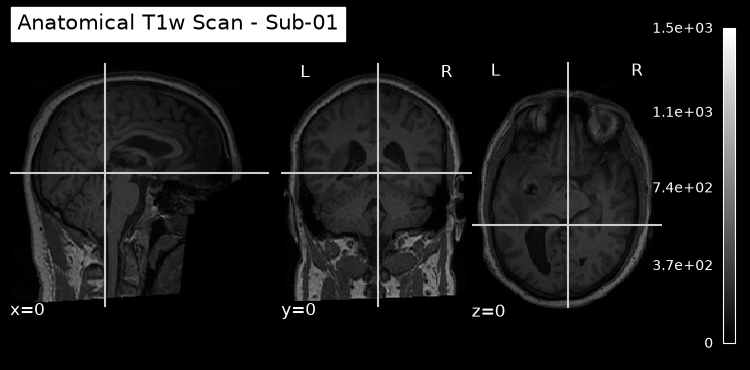

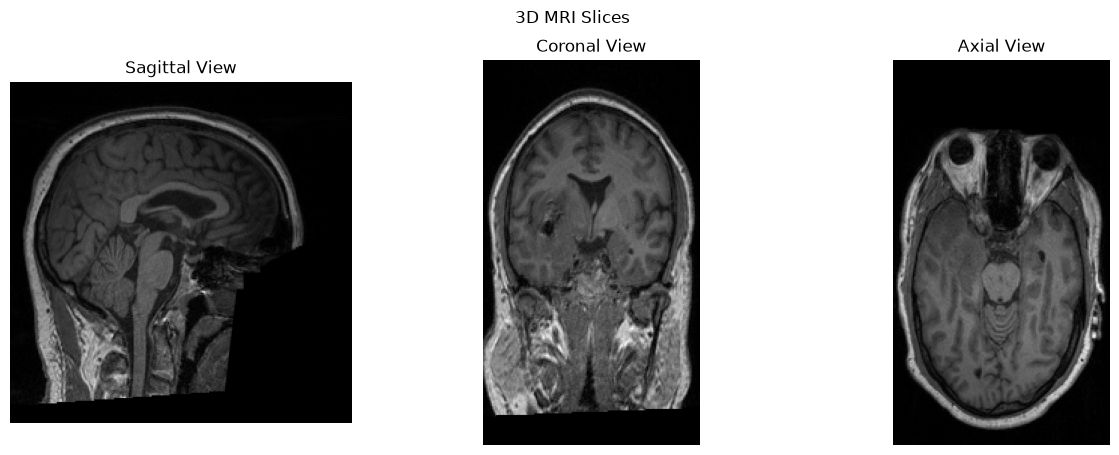

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting

# 1. Define file path (replace with your local path)
file_path = "./dataset/sub-RS005/ses-1/anat/sub-RS005_ses-1_T1w.nii.gz"

# 2. Load the NIfTI object
img = nib.load(file_path)

# 3. Access image metadata and voxel data
data = img.get_fdata()  # Extracts the 3D or 4D numpy array
affine = img.affine      # Spatial orientation matrix (transforms voxel indices to mm)

print(f"Data Shape: {data.shape}")
print(f"Data Type: {data.dtype}")
print(f"Affine Matrix:\n{affine}")

# -------------------------------------------------------------
# Option A: Quick Visualization using Nilearn
# -------------------------------------------------------------
plotting.plot_anat(
    img, 
    title="Anatomical T1w Scan - Sub-01", 
    display_mode="ortho", 
    cut_coords=(0, 0, 0)
)
plotting.show()

# -------------------------------------------------------------
# Option B: Manual Slicing with Matplotlib & NumPy
# -------------------------------------------------------------
# Select central slices across dimensions
mid_x = data.shape[0] // 2
mid_y = data.shape[1] // 2
mid_z = data.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.rot90(data[mid_x, :, :]), cmap="gray")
axes[0].set_title("Sagittal View")
axes[0].axis("off")

axes[1].imshow(np.rot90(data[:, mid_y, :]), cmap="gray")
axes[1].set_title("Coronal View")
axes[1].axis("off")

axes[2].imshow(np.rot90(data[:, :, mid_z]), cmap="gray")
axes[2].set_title("Axial View")
axes[2].axis("off")

plt.suptitle("3D MRI Slices")
plt.show()

## Visual interactive interface for MRI scans.

An interactive interface is created that allows users to visualize the MRI scans in different planes (axial, sagittal, and coronal) and navigate through the slices. The interface provides a slider to adjust the slice index and buttons to switch between different views. This allows users to explore the MRI scans and perform the following:
- Find the approximate/possible region of the tumor in the brain.
- Structure and plan image scanning to confirm the presence of the tumor in the brain.
- Understand the brain image patterns and ensure to avoid any false positives in the tumor detection process.
- Find edge cases to avoid false negatives in the tumor detection process.

After making these considerations, wee can proceed with the development of the image scanning and analysis and perform necessary image processing techniques to detect the tumor in the brain. The interface will also allow users to visualize the results of the tumor detection process and compare them with the original MRI scans.

In [2]:
import nibabel as nib
import numpy as np
from vedo import Volume
from vedo.applications import Slicer3DPlotter
import vedo

# Set the output to native GUI
vedo.settings.default_backend = "vtk"

def launch_mricrogl_ui(nii_path):
    # 1. Load the NIfTI image using nibabel
    nii_img = nib.load(nii_path)

    # 2. Get the raw image volume matrix
    data = nii_img.get_fdata()

    # 3. Retrieve voxel sizes (spacing) to prevent spatial distortion
    spacing = nii_img.header.get_zooms()[:3]

    # 4. Convert into a Vedo Volume object
    # Note: reorder spacing to match the transposed axes (z, y, x)
    transposed_data = np.transpose(data, (2, 1, 0))
    transposed_spacing = (spacing[2], spacing[1], spacing[0])
    vol = Volume(transposed_data, spacing=transposed_spacing)

    # 5. Initialize the MRIcroGL-style 3-plane interactive slicer window
    plt = Slicer3DPlotter(
        vol,
        cmaps=["grey"],
        # alpha=1.0,
        bg="dark grey",
        axes=1,
    )

    # 6. Render and open the interface
    plt.show(title="MRIcroGL Clone Viewer (vedo)")

launch_mricrogl_ui("./dataset/sub-RS005/ses-1/anat/sub-RS005_ses-1_T1w.nii.gz")